# Trabajo Grupal 1 — VIIRS Active Fires in Peru (2012–2024)
## Curso: Geo Agents · IA Generativa para el Análisis Geoespacial

**Integrantes:** Alexander Junior Carrillo Chávez · Antony Alejandro Velásquez Perez

### El problema

Analizamos las detecciones de **fuegos activos del sensor VIIRS** (producto VIIRS Active Fire, satélite **Suomi‑NPP** / NASA FIRMS) para el Perú entre **2013 y 2024**. El objetivo es agregar los fuegos a nivel de **distrito** y cruzarlos con la **cobertura vegetal** (raster VCF, MOD44B, año 2003) para aislar y caracterizar los **incendios forestales**.

# Parte 0 · Configuración base

Aquí se realiza la instalación de librerías, importación de módulos, cencisión de permisos para acceso al drive, y carga de capas geográficas.

### 0.1 · Instalación de librerías

In [40]:
# Instalación de paqueterías necesarias
!pip install -q geopandas folium mapclassify rioxarray rasterio rasterstats dask "dask-geopandas" pyarrow
print("Librerías instaladas")

Librerías instaladas


### 0.2 · Imports y parámetros globales


In [41]:
# Realizamos imports
import warnings; warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# Rango de años de la actividad
YEAR_START, YEAR_END = 2013, 2024
print(f"Periodo de análisis: {YEAR_START}–{YEAR_END}")

Periodo de análisis: 2013–2024


### 0.3 · Ruta al raster VCF



In [42]:
!wget -O tree_cover_2003.tif "https://www.dropbox.com/scl/fi/a3c2tdgb7urvbxrmqjaox/MOD44B.061_Percent_Tree_Cover_2003Peru.tif?rlkey=1v8v271e4gn2mnnwhrc3gbp4f&dl=1"

--2026-07-14 00:47:31--  https://www.dropbox.com/scl/fi/a3c2tdgb7urvbxrmqjaox/MOD44B.061_Percent_Tree_Cover_2003Peru.tif?rlkey=1v8v271e4gn2mnnwhrc3gbp4f&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.80.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.80.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc65d16ff765debb6d045fb51c0e.dl.dropboxusercontent.com/cd/0/inline/DEMpr3qNFIzqYfMl-L72hg4Dye0glKPT34monkBA8Tmo-iGm5egsnUHxhG9nhfUpWIie85DQKZtzaEGa66AjDQ_2p1iluQVfp8gNw2b8KASOxo6PICpwWKeeD0nxtTVv0_nZVP4qBQU88bcfDVZZEwhq/file?dl=1# [following]
--2026-07-14 00:47:32--  https://uc65d16ff765debb6d045fb51c0e.dl.dropboxusercontent.com/cd/0/inline/DEMpr3qNFIzqYfMl-L72hg4Dye0glKPT34monkBA8Tmo-iGm5egsnUHxhG9nhfUpWIie85DQKZtzaEGa66AjDQ_2p1iluQVfp8gNw2b8KASOxo6PICpwWKeeD0nxtTVv0_nZVP4qBQU88bcfDVZZEwhq/file?dl=1
Resolving uc65d16ff765debb6d045fb51c0e.dl.dropboxusercontent.com (uc65d16ff765debb6d045fb51c0e.dl.

In [43]:
# Ruta al VCF (MOD44B, % cobertura arbórea 2003) dentro de Drive
VCF_PATH = "/content/tree_cover_2003.tif"

### 0.5 · Fuentes de datos vectoriales (GADM 4.1)

Cargamos los límites administrativos del Perú desde **GADM 4.1**:
- **Distritos** (nivel 3, ~1815 polígonos) → nuestra unidad "municipio" para agregar los fuegos.
- **Departamentos** (nivel 1) → unidad para la serie temporal de la Parte 5.

In [44]:
# Distritos (nivel 3) — unidad "municipio"
distritos = gpd.read_file(
    "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PER_3.json"
)
distritos = distritos[["GID_3", "NAME_3", "NAME_2", "NAME_1", "geometry"]].copy()

# Departamentos (nivel 1) — para la serie temporal (Parte 5)
departamentos = gpd.read_file(
    "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PER_1.json"
)[["GID_1", "NAME_1", "geometry"]].copy()

print(f"Distritos    : {len(distritos)}  | CRS: {distritos.crs}")
print(f"Departamentos: {len(departamentos)} | CRS: {departamentos.crs}")
distritos.head(3)

Distritos    : 1815  | CRS: EPSG:4326
Departamentos: 26 | CRS: EPSG:4326


,GID_3,NAME_3,NAME_2,NAME_1,geometry
0,PER.1.1.1_1,Aramango,Bagua,Amazonas,"MULTIPOLYGON (((-78.2964 -5.5489, -78.3031 -5...."
1,PER.1.1.2_1,Copallin,Bagua,Amazonas,"MULTIPOLYGON (((-78.3637 -5.5754, -78.3594 -5...."
2,PER.1.1.3_1,ElParco,Bagua,Amazonas,"MULTIPOLYGON (((-78.4739 -5.645, -78.4838 -5.6..."


# Parte 1 · Mapa choropleth estático (2024)

**Objetivo:** mapa estático con GeoPandas del **total de fuegos por distrito** en el año **2024**.


### 1.1 · Descargar fuegos VIIRS 2024


In [45]:
# VIIRS-SNPP (Suomi-NPP), fuegos de Perú 2024 desde NASA FIRMS
YEAR = 2024
url = f"https://firms.modaps.eosdis.nasa.gov/data/country/viirs-snpp/{YEAR}/viirs-snpp_{YEAR}_Peru.csv"
fires_raw = pd.read_csv(url)

fires_2024 = gpd.GeoDataFrame(
    fires_raw,
    geometry=gpd.points_from_xy(fires_raw.longitude, fires_raw.latitude),
    crs="EPSG:4326",
)
print(f"Fuegos 2024: {len(fires_2024):,} detecciones")
fires_2024[["latitude","longitude","frp","confidence","acq_time"]].head(3)

Fuegos 2024: 99,932 detecciones


,latitude,longitude,frp,confidence,acq_time
0,-16.64335,-72.60129,1.77,n,610
1,-16.64675,-72.60179,2.65,n,610
2,-15.78601,-71.85581,5.36,n,610


### 1.2 · Spatial join y conteo por distrito


In [46]:
# Asignar cada detección a su distrito
fires_x_dist = gpd.sjoin(
    fires_2024[["frp", "confidence", "geometry"]],
    distritos, how="inner", predicate="within",
)

# Conteo por distrito
conteo = fires_x_dist.groupby("GID_3").size().rename("n_fires").reset_index()

# Unir a los polígonos; distritos sin fuegos = 0
dist_fires = distritos.merge(conteo, on="GID_3", how="left")
dist_fires["n_fires"] = dist_fires["n_fires"].fillna(0).astype(int)

print(f"Fuegos asignados a un distrito: {len(fires_x_dist):,} de {len(fires_2024):,}")
print(f"Distritos con al menos 1 fuego: {(dist_fires.n_fires > 0).sum()} de {len(dist_fires)}")
dist_fires.sort_values("n_fires", ascending=False)[["NAME_3","NAME_1","n_fires"]].head(5)

Fuegos asignados a un distrito: 99,773 de 99,932
Distritos con al menos 1 fuego: 1499 de 1815


,NAME_3,NAME_1,n_fires
1809,NuevaRequena,Ucayali,3763
1805,Callaria,Ucayali,2282
1456,Iberia,MadredeDios,2159
1812,Irazola,Ucayali,1907
1806,Campoverde,Ucayali,1760


### 1.3 · Choropleth


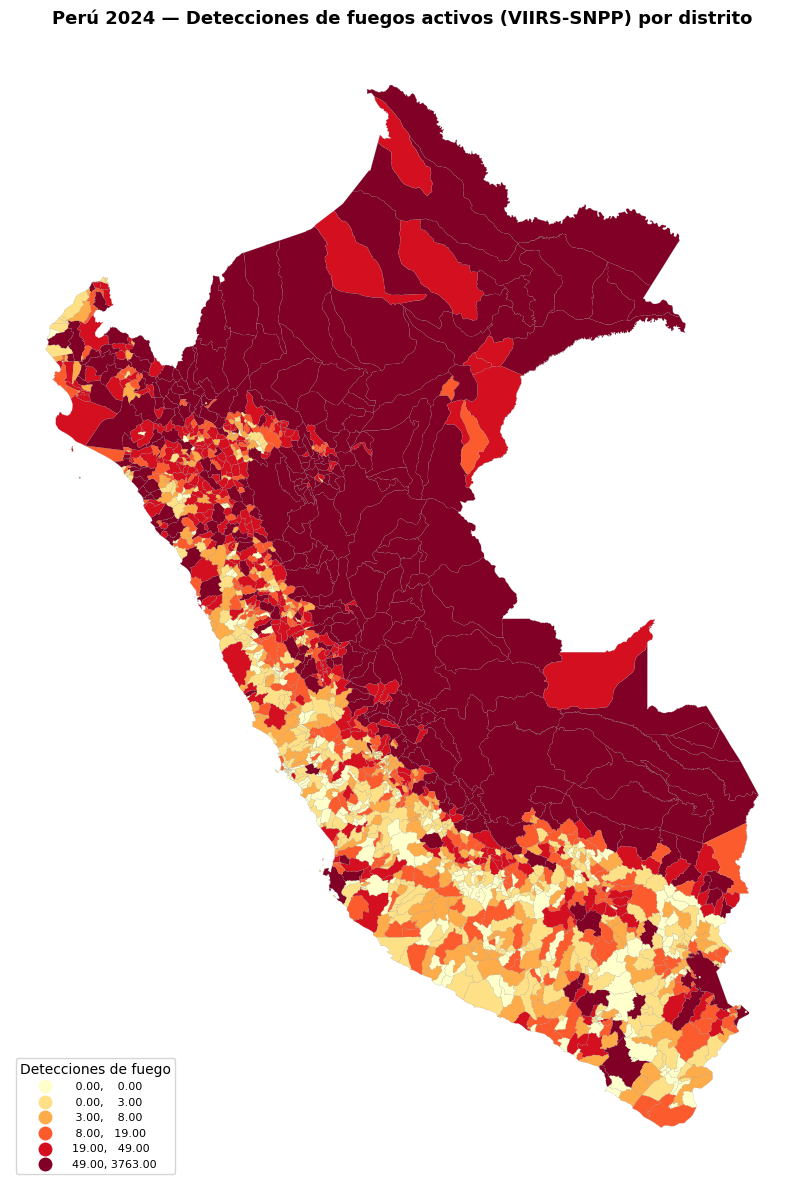

Guardado: task1_choropleth_2024.png


In [52]:
# Choropleth estático con GeoPandas
fig, ax = plt.subplots(figsize=(10, 12))
dist_fires.plot(
    column="n_fires", cmap="YlOrRd", scheme="quantiles", k=6, legend=True,
    legend_kwds={"title": "Detecciones de fuego", "loc": "lower left", "fontsize": 8},
    edgecolor="grey", linewidth=0.1,
    missing_kwds={"color": "#f0f0f0"}, ax=ax,
)
ax.set_title("Perú 2024 — Detecciones de fuegos activos (VIIRS-SNPP) por distrito",
             fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("task1_choropleth_2024.png", dpi=200, bbox_inches="tight")
plt.show()
print("Guardado: task1_choropleth_2024.png")

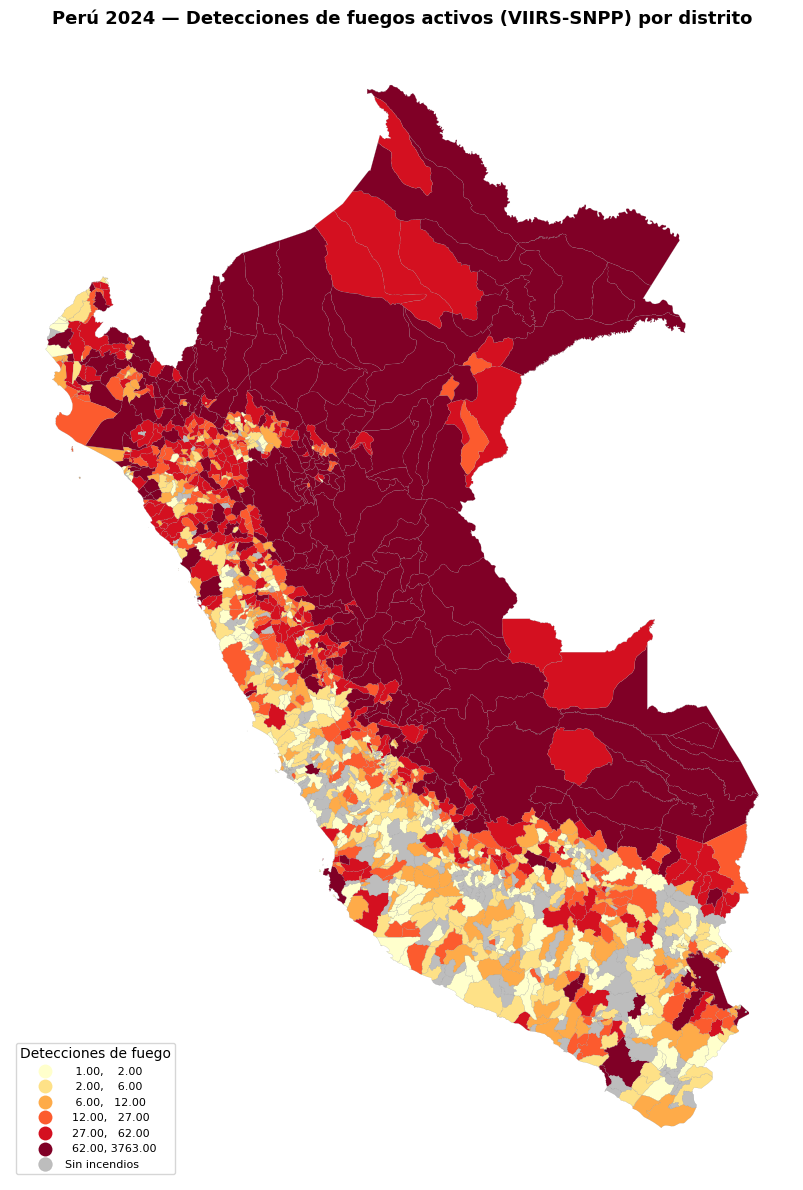

In [53]:
# Choropleth estático con GeoPandas
fig, ax = plt.subplots(figsize=(10, 12))

# Los 0 pasan a NaN -> se pintan con missing_kwds
dist_fires['n_fires_temp'] = dist_fires['n_fires'].replace(0, np.nan)

dist_fires.plot(
    column="n_fires_temp",
    cmap="YlOrRd", scheme="quantiles", k=6, legend=True,
    legend_kwds={"title": "Detecciones de fuego", "loc": "lower left", "fontsize": 8},
    edgecolor="grey", linewidth=0.1,
    missing_kwds={
        "color": "#bdbdbd",
        "edgecolor": "grey",
        "linewidth": 0.1,
        "label": "Sin incendios",
    },
    ax=ax,
)
ax.set_title("Perú 2024 — Detecciones de fuegos activos (VIIRS-SNPP) por distrito",
             fontsize=13, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("task1_choropleth_2024_v2.png", dpi=200, bbox_inches="tight")
plt.show()

# Parte 2 · Mapa dinámico — Top 100 fuegos de 2024

**Objetivo:** mapa interactivo (folium) con los **100 fuegos más intensos de 2024**, cada uno como un círculo cuyo radio es proporcional a la intensidad (`frp`).

### 2.1 · Seleccionar el Top 100 por FRP

In [54]:
# Los 100 fuegos más intensos de 2024
top100 = fires_2024.nlargest(100, "frp").copy()
print(f"FRP máximo: {top100.frp.max():,.1f} MW  |  FRP mínimo del top 100: {top100.frp.min():,.1f} MW")
top100[["latitude", "longitude", "frp", "confidence", "acq_date"]].head(5)

FRP máximo: 645.8 MW  |  FRP mínimo del top 100: 204.1 MW


,latitude,longitude,frp,confidence,acq_date
29240,-7.51388,-76.48359,645.80,l,2024-08-19
75254,-10.37600,-74.88297,406.80,h,2024-09-24
82607,-13.92075,-71.74660,387.54,l,2024-10-07
92309,-16.64363,-71.09019,378.79,l,2024-10-31
92311,-16.63966,-71.09179,378.79,l,2024-10-31


### 2.2 · Mapa folium

In [55]:
import folium

m = folium.Map(location=[-9.2, -74.5], zoom_start=5, tiles="CartoDB positron")

def radio(frp, factor=1.1):
    return factor * np.sqrt(frp)

for _, row in top100.iterrows():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=radio(row.frp),
        color="#d62728", fill=True, fill_color="#ff7f0e",
        fill_opacity=0.6, weight=1,
        popup=folium.Popup(
            f"<b>FRP:</b> {row.frp:,.1f} MW<br>"
            f"<b>Fecha:</b> {row.acq_date} {row.acq_time}<br>"
            f"<b>Confianza:</b> {row.confidence}", max_width=200,
        ),
    ).add_to(m)

m.save("task2_top100_fires_2024.html")
print("Guardado: task2_top100_fires_2024.html")
m

Guardado: task2_top100_fires_2024.html


# Parte 3 · Distritos con bosque sobre la mediana (VCF)

**Objetivo:** con el raster VCF, calcular el **% promedio de bosque por distrito** y quedarnos con los distritos **por encima de la mediana**.

Punto crítico: el raster está en proyección **MODIS Sinusoidal** (metros), no en EPSG:4326. La regla es reproyectar el **vector al CRS del raster** (barato, no degrada el raster), nunca al revés.

### 3.1 · Inspeccionar el raster

Antes de procesar, revisamos CRS, número de bandas, nodata y rango de valores. .

In [56]:
import rasterio

with rasterio.open(VCF_PATH) as src:
    print(f"CRS        : {src.crs}")
    print(f"Bandas     : {src.count}  (debe ser 1)")
    print(f"Tamaño     : {src.width} x {src.height} px")
    print(f"Resolución : {src.res}")
    print(f"NoData     : {src.nodata}")
    print(f"Bounds     : {src.bounds}")
    _banda = src.read(1)
print(f"\nValores banda -> min: {_banda.min()}, max: {_banda.max()}, media: {_banda.mean():.1f}")

CRS        : PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bandas     : 1  (debe ser 1)
Tamaño     : 8480 x 9012 px
Resolución : (231.6563582625, 231.6563582625)
NoData     : 253.0
Bounds     : BoundingBox(left=-9147646.2750696, bottom=-2079810.7844807247, right=-7183200.3570036, top=7876.316180925141)

Valores banda -> min: 0, max: 253, media: 129.2


### 3.2 · Zonal statistics — % promedio de bosque por distrito


In [57]:
# Agregar el VCF a nivel de distrito (media del % de cobertura arbórea)
from rasterstats import zonal_stats

SENT = -9999.0  # centinela para nodata

with rasterio.open(VCF_PATH) as src:
    arr = src.read(1).astype("float32")
    affine = src.transform
    raster_crs = src.crs

arr[arr > 100] = SENT   # enmascarar relleno (agua/sin dato)
print(f"% árbol válido -> min: {arr[arr!=SENT].min():.0f}, "
      f"max: {arr[arr!=SENT].max():.0f}, media: {arr[arr!=SENT].mean():.1f}")

# Se debe reproyectar los distritos al CRS del raster (Sinusoidal)
distritos_sin = distritos.to_crs(raster_crs)

stats = zonal_stats(distritos_sin, arr, affine=affine, nodata=SENT,
                    stats=["mean"], all_touched=False)

distritos_vcf = distritos.copy()
distritos_vcf["forest_pct"] = [s["mean"] for s in stats]
print(f"\nDistritos con valor de bosque: {distritos_vcf['forest_pct'].notna().sum()} de {len(distritos_vcf)}")
distritos_vcf.sort_values("forest_pct", ascending=False)[["NAME_3","NAME_1","forest_pct"]].head(5)

% árbol válido -> min: 0, max: 87, media: 53.2

Distritos con valor de bosque: 1814 de 1815


,NAME_3,NAME_1,forest_pct
1434,Putumayo,Loreto,78.915587
1430,LasAmazonas,Loreto,78.068702
1437,AltoTapiche,Loreto,77.920718
1432,Napo,Loreto,77.760360
1426,AltoNanay,Loreto,77.636046


### 3.3 · Selección por mediana

Mediana del % de bosque entre distritos: 6.47%
Distritos seleccionados (bosque > mediana): 907 de 1815


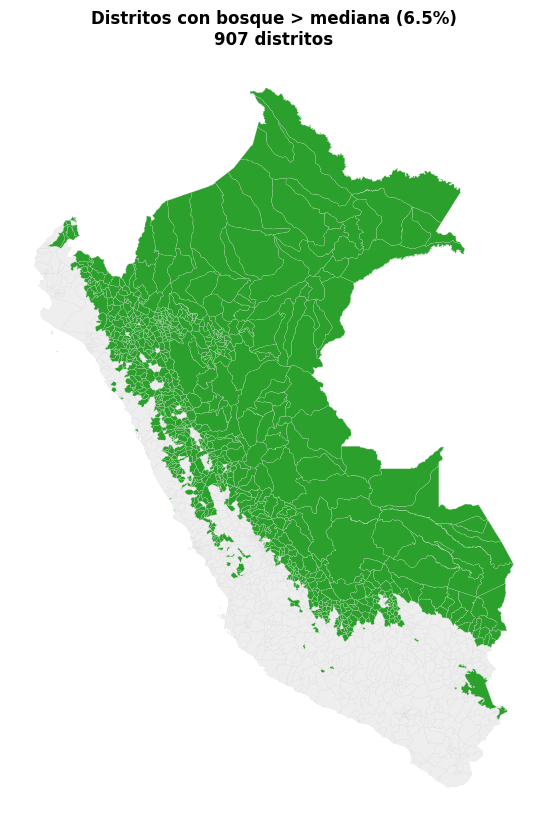

Guardado: task3_distritos_bosque.png


In [58]:
# Distritos con bosque > mediana
mediana = distritos_vcf["forest_pct"].median()
print(f"Mediana del % de bosque entre distritos: {mediana:.2f}%")

distritos_bosque = distritos_vcf[distritos_vcf["forest_pct"] > mediana].copy()
print(f"Distritos seleccionados (bosque > mediana): {len(distritos_bosque)} de {len(distritos_vcf)}")

fig, ax = plt.subplots(figsize=(8, 10))
distritos_vcf.plot(ax=ax, color="#eeeeee", edgecolor="#cccccc", linewidth=0.1)
distritos_bosque.plot(ax=ax, color="#2ca02c", edgecolor="white", linewidth=0.1)
ax.set_title(f"Distritos con bosque > mediana ({mediana:.1f}%)\n{len(distritos_bosque)} distritos",
             fontweight="bold")
ax.set_axis_off()


plt.savefig("task3_distritos_bosque.png", dpi=200, bbox_inches="tight")  # guardar PNG
plt.show()
print("Guardado: task3_distritos_bosque.png")


# Parte 4 · Filtrado de fuegos por píxel de vegetación > 50%

**Objetivo:** para los distritos seleccionados en la Parte 3, quedarnos solo con los fuegos que caen en un **píxel con vegetación > 50%**, a lo largo de **todos los años (2012–2024)**.


### 4.1 · Descargar todos los años (2012–2024)


In [59]:
# Descargar VIIRS-SNPP para todo el periodo
frames = []
for year in range(YEAR_START, YEAR_END + 1):
    url = f"https://firms.modaps.eosdis.nasa.gov/data/country/viirs-snpp/{year}/viirs-snpp_{year}_Peru.csv"
    try:
        df = pd.read_csv(url, usecols=["latitude","longitude","frp","confidence","acq_date","acq_time"])
        df["year"] = year
        frames.append(df)
        print(f"{year}: {len(df):,} fuegos")
    except Exception as e:
        print(f"{year}: ERROR -> {e}")

fires_df = pd.concat(frames, ignore_index=True)
fires_all = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df.longitude, fires_df.latitude),
    crs="EPSG:4326",
)
print(f"\nTOTAL 2012–2024: {len(fires_all):,} detecciones")

2013: 64,406 fuegos
2014: 57,655 fuegos
2015: 69,996 fuegos
2016: 91,343 fuegos
2017: 57,168 fuegos
2018: 63,185 fuegos
2019: 74,411 fuegos
2020: 98,416 fuegos
2021: 67,345 fuegos
2022: 89,579 fuegos
2023: 79,577 fuegos
2024: 99,932 fuegos

TOTAL 2012–2024: 913,013 detecciones


### 4.2 · Restringir a los distritos con bosque


In [60]:
# Spatial join de TODOS los fuegos con los distritos
fires_dist = gpd.sjoin(
    fires_all,
    distritos[["GID_3","NAME_3","NAME_1","geometry"]],
    how="inner", predicate="within",
).drop(columns="index_right")
print(f"Fuegos dentro de algún distrito: {len(fires_dist):,}")

# Solo fuegos en distritos con bosque > mediana
sel_ids = set(distritos_bosque["GID_3"])
fires_sel = fires_dist[fires_dist["GID_3"].isin(sel_ids)].copy()
print(f"Fuegos en distritos con bosque > mediana: {len(fires_sel):,}")

Fuegos dentro de algún distrito: 911,825
Fuegos en distritos con bosque > mediana: 794,999


### 4.3 · Muestreo del raster y filtro > 50%



In [61]:
# Valor del píxel VCF bajo cada fuego → filtrar > 50%

# 1) Reproyectar los fuegos seleccionados al CRS del raster (Sinusoidal)
pts = fires_sel.to_crs(raster_crs)
xs = pts.geometry.x.values
ys = pts.geometry.y.values

# 2) Coordenadas -> índices fila/columna con la transformada inversa
inv = ~affine
cols, rows = inv * (xs, ys)
cols = np.floor(cols).astype(int)
rows = np.floor(rows).astype(int)

# 3) Leer el valor del píxel (con control de límites)
h, w = arr.shape
valid = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
pix = np.full(len(xs), np.nan, dtype="float32")
pix[valid] = arr[rows[valid], cols[valid]]

fires_sel = fires_sel.copy()
fires_sel["forest_pixel_pct"] = pix

# 4) Filtro final: fuegos forestales = píxel de vegetación > 50%
fires_forest = fires_sel[fires_sel["forest_pixel_pct"] > 50].copy()

print(f"Fuegos en distritos seleccionados : {len(fires_sel):,}")
print(f"Fuegos forestales (píxel > 50%)   : {len(fires_forest):,}")
print(f"Retención: {100*len(fires_forest)/len(fires_sel):.1f}%")

Fuegos en distritos seleccionados : 794,999
Fuegos forestales (píxel > 50%)   : 506,065
Retención: 63.7%


# Parte 5 · Serie temporal por departamento (2013–2024)

**Objetivo:** con los fuegos forestales ya filtrados, graficar la evolución 2013–2024 del total de incendios forestales por **departamento**, usando **solo detecciones de alta confianza** (`confidence == "h"`).

### 5.1 · Filtro de alta confianza y agregación


In [62]:
# Solo fuegos de alta confianza, 2013–2024
fires_high = fires_forest[
    (fires_forest["confidence"] == "h") &
    (fires_forest["year"].between(2013, 2024))
].copy()
print(f"Fuegos forestales de alta confianza (2013–2024): {len(fires_high):,}")

serie = (fires_high.groupby(["year", "NAME_1"]).size()
         .rename("n_fires").reset_index())
serie_wide = serie.pivot(index="year", columns="NAME_1", values="n_fires").fillna(0)
print("Top departamentos por total de fuegos forestales:")
serie_wide.sum().sort_values(ascending=False).head(8)

Fuegos forestales de alta confianza (2013–2024): 21,981
Top departamentos por total de fuegos forestales:


,0
NAME_1,
Ucayali,5629.0
SanMartín,3602.0
Huánuco,3517.0
MadredeDios,3232.0
Loreto,2052.0
Junín,1675.0
Pasco,870.0
Cusco,666.0


### 5.2 · Gráfico de serie temporal


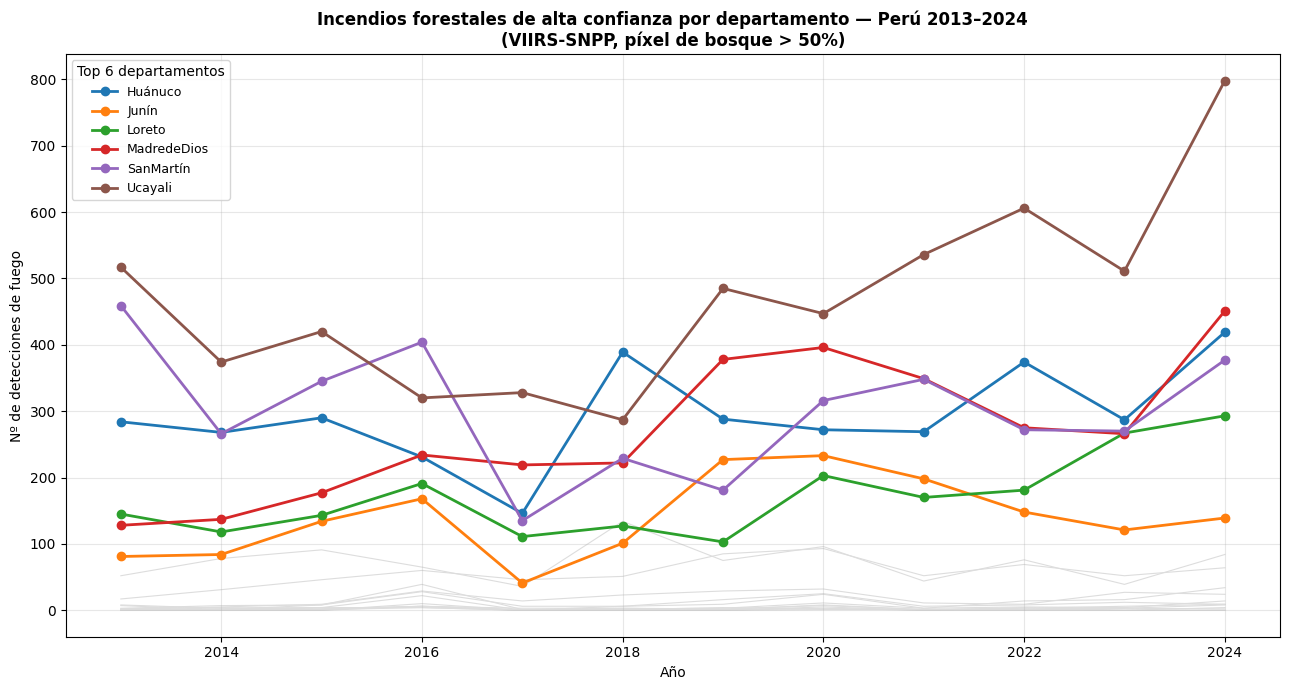

Guardado: task5_serie_temporal_departamento.png


In [29]:
# Serie temporal por departamento
fig, ax = plt.subplots(figsize=(13, 7))
top_deps = serie_wide.sum().sort_values(ascending=False).head(6).index

for dep in serie_wide.columns:
    if dep in top_deps:
        ax.plot(serie_wide.index, serie_wide[dep], marker="o", linewidth=2, label=dep)
    else:
        ax.plot(serie_wide.index, serie_wide[dep], color="#dddddd", linewidth=0.8, zorder=0)

ax.set_title("Incendios forestales de alta confianza por departamento — Perú 2013–2024\n"
             "(VIIRS-SNPP, píxel de bosque > 50%)", fontweight="bold", fontsize=12)
ax.set_xlabel("Año"); ax.set_ylabel("Nº de detecciones de fuego")
ax.legend(title="Top 6 departamentos", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("task5_serie_temporal_departamento.png", dpi=200, bbox_inches="tight")
plt.show()
print("Guardado: task5_serie_temporal_departamento.png")

# Documentación metodológica

**Rango de años.** Se descargaron detecciones VIIRS 2012–2024. La Parte 1 (choropleth) y la Parte 2 (Top 100) usan **2024**; la Parte 5 (serie temporal) usa **2013–2024**.

**Filtro de confianza.** El producto VIIRS codifica la confianza como `l` (low), `n` (nominal) y `h` (high). Para la serie temporal (Parte 5) se conservaron **solo las detecciones de alta confianza** (`confidence == "h"`). Las Partes 1–4 usan todas las confianzas.

**Satélite.** Se usó el producto **VIIRS Active Fire del satélite Suomi‑NPP (VIIRS‑SNPP)**, descargado del servicio de país de NASA FIRMS.

**Cobertura vegetal.** Raster **MOD44B (Vegetation Continuous Fields), % de cobertura arbórea del año 2003**, banda única en proyección MODIS Sinusoidal. Es una línea base estática de 2003 superpuesta a fuegos 2012–2024. Se reproyectaron los vectores al CRS del raster y se enmascararon los valores de relleno (>100).

**Herramienta de la Parte 4 y justificación.**
Para la Parte 4 se tenia que cruzar más de un millón de detecciones de fuego contra el raster de vegetación. Si bien el camino más obvio seria convertir el raster en polígonos y hacer un cruce espacial, eso no es posible porque genera millones de polígonos y requeriria demasiados recursos computacionales para su tratamiento.

Sin embargo, de esta forma se resuelve de una manera más directa, dado que como el raster es una cuadricula regular, a cada fuego se calcula en que celda cae, a través de la transformada inversa del raster para pasar de coordenadas a fila y columna. De esta forma, se evita el bucle punto por punto, y se utiliza una indexación vectorizada de NumPy, que proceso el millón de puntos en una sola pasada.

### Entregables generados
- `task1_choropleth_2024.png` — mapa estático de fuegos por distrito (2024).
- `task2_top100_fires_2024.html` — mapa dinámico Top 100 (folium).
- `task3_distritos_bosque.png` — mapa de distritos con bosque superior a la mediana
- `task5_serie_temporal_departamento.png` — serie temporal por departamento.